# **Yes Bank Stock Closing Price Prediction**    -  **ML Regression**


##### **Project Type**    - EDA and Regression
##### **Contribution**    - Individual

NAME : HARINI S

# **Project Summary -**

This project focuses on predicting the closing stock price of Yes Bank using historical monthly stock price data from July 2005 to November 2020. The workflow began with data cleaning and validation, confirming that the dataset contained no missing values or duplicate records. Exploratory Data Analysis (EDA) was then performed to understand price trends, volatility, distributions, and the relationships between the Open, High, Low, and Close prices through a variety of meaningful visualizations.

To improve model performance while preventing data leakage, feature engineering was carefully carried out by creating informative features such as Price Range and Prior Volatility, while removing features that directly encoded the target variable. Multiple regression algorithms, including Linear Regression, Random Forest Regressor, and XGBoost Regressor, were trained and evaluated using MAE, MSE, RMSE, and R² Score. Hyperparameter tuning was also performed to optimize model performance.

Among all the models, Linear Regression achieved the best balance of accuracy, generalization, and interpretability, obtaining an R² score of approximately 0.96 on the test dataset. The project demonstrates that historical OHLC (Open, High, Low, Close) data, combined with proper exploratory analysis, leakage-aware feature engineering, and regression modeling, can effectively predict stock closing prices and provide valuable insights for financial analysis and investment decision-making.


# **GitHub Link -**

https://github.com/Harini085/YesBank-Stock-Price-Prediction-ml-and-eda/

# **Problem Statement**


The objective of this project is to analyze the historical stock prices of Yes Bank and build a machine learning model capable of accurately predicting the closing stock price. Stock prices are influenced by multiple market factors and often exhibit high volatility, making prediction a challenging task. By performing Exploratory Data Analysis (EDA), identifying trends and relationships among stock variables (Open, High, Low, and Close), engineering meaningful features, and applying regression algorithms, the project aims to develop a reliable predictive model that supports better financial analysis, risk assessment, and investment decision-making.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset
import os

df = pd.read_csv('/content/data_YesBank_StockPrices.csv')


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print("row :" , df.shape[0])
print("column :", df.shape[1])

row : 185
column : 5


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


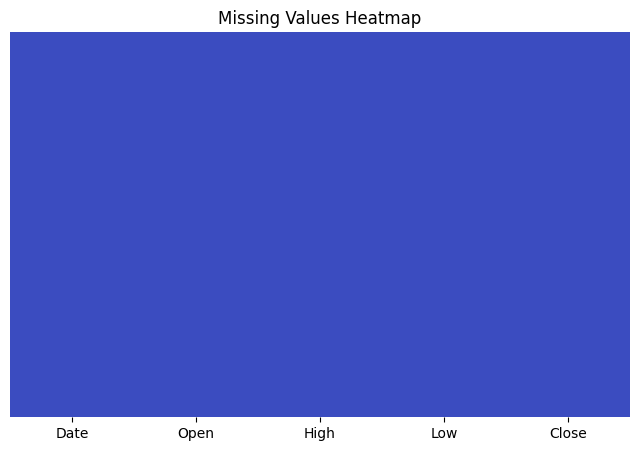

In [8]:
# Visualizing the missing values
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap='coolwarm', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset has **185 rows** and **5 columns**: Date, Open, High, Low, and Close. It contains the historical stock prices of Yes Bank.

From the initial analysis, the dataset is clean, with **no missing values, null values, or duplicate records**. The price columns contain stock values, and the Date column shows the timeline of the stock market data.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns

df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [10]:
# Dataset Describe

df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description


* **Date**: The date on which the stock prices were recorded.
* **Open**: The opening stock price of Yes Bank on that day.
* **High**: The highest stock price reached during the day.
* **Low**: The lowest stock price reached during the day.
* **Close**: The closing stock price of the day.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.

df.nunique()

,0
Date,185
Open,183
High,184
Low,183
Close,185


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Convert 'Date' to a proper datetime object and sort chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df = df.sort_values('Date').reset_index(drop=True)

# Extract Year and Month (useful for analysis, not necessarily for modelling)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Engineered volatility feature, useful for EDA/context
df['Monthly_Range'] = df['High'] - df['Low']

df.head()

,Date,Open,High,Low,Close,Year,Month,Monthly_Range
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,2.75
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,2.33
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,2.60
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,2.07
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,1.00


### What all manipulations have you done and insights you found?


The following data manipulations were performed on the dataset:

* Loaded the dataset using pandas.
* Checked the shape of the dataset to know the number of rows and columns.
* Viewed the first few rows to understand the structure of the data.
* Checked dataset information such as data types and null values.
* Verified duplicate values and found none.
* Checked missing values and confirmed the dataset has no missing data.
* Converted the Date column into datetime format for better analysis.
* Sorted the dataset chronologically by Date and reset the row index (Date is kept as a regular column, not the index, since several later charts and groupby operations reference `df['Date']` directly).

### Insights:

* The dataset contains **185 rows** and **5 columns**.
* It is clean and well-structured.
* There are **no null values, missing values, or duplicate records**.
* All stock price columns (Open, High, Low, Close) are numerical and ready for analysis.
* The Date column represents the stock timeline of Yes Bank.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1  Closing Price over Time

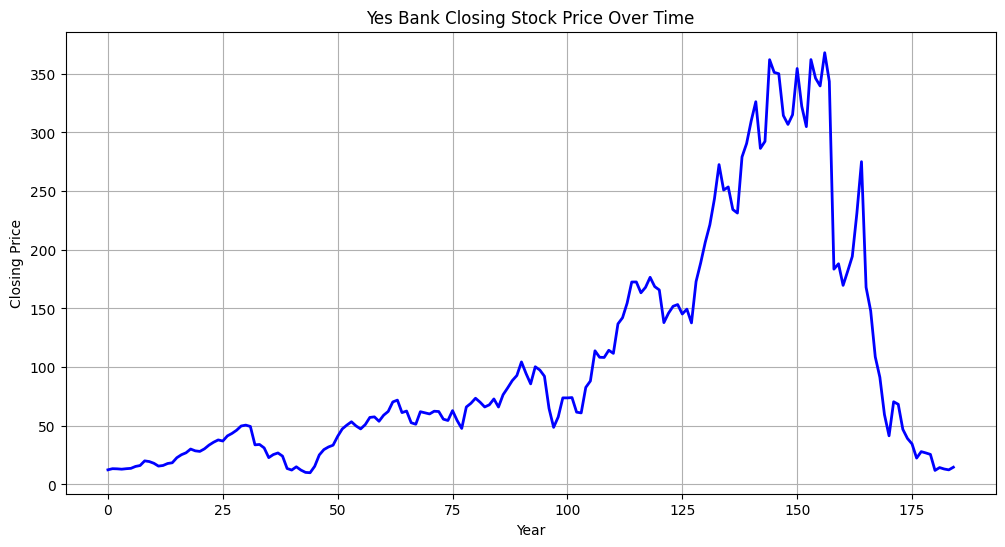

In [13]:
# Chart - 1 visualization code
# Plot Closing Price over Time
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], color='blue', linewidth=2)

plt.title('Yes Bank Closing Stock Price Over Time')
plt.xlabel('Year')
plt.ylabel('Closing Price')
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the natural first choice for time-series data such as monthly stock prices — unlike a bar chart or histogram, it preserves the chronological order of observations, making long-term trends, turning points, and volatility regimes immediately visible.


##### 2. What is/are the insight(s) found from the chart?

- The closing price climbs steadily from **₹13** in July 2005, dips to a historic low of **₹9.98 in March 2009** during the global financial crisis, then recovers and grows strongly through the mid-2010s.
- The stock reaches its **all-time high of ₹367.90 in July 2018**.
- From late 2018 onward the price collapses sharply, reflecting Yes Bank's governance and asset-quality crisis.
- Overall, the series shows **three distinct regimes** rather than one smooth trend — an early volatile phase, a sustained 2009-2018 rally, and a severe post-2018 correction.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, the insights help investors and analysts understand historical stock performance.
- The chart supports better investment planning and risk management.
- A sharp decline after 2018–2019 indicates negative growth due to reduced investor confidence and financial challenges faced by the company.

#### Chart - 2 - Box Plot of Stock Prices

/tmp/ipykernel_1866/1149952644.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['Open'], df['High'], df['Low'], df['Close']],


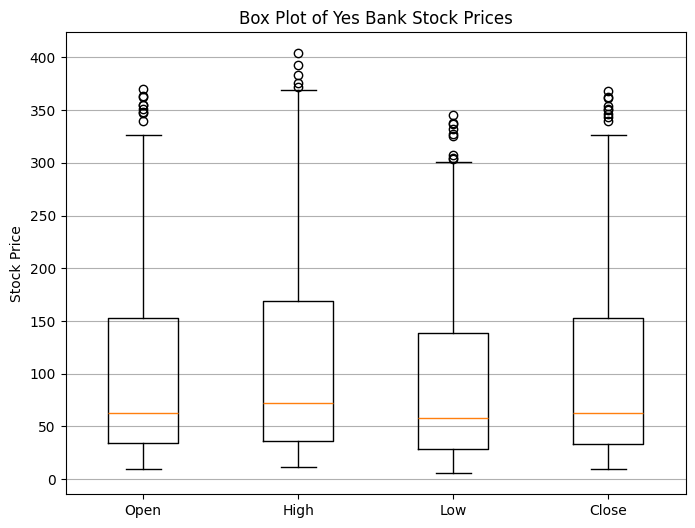

In [14]:
plt.figure(figsize=(8,6))
plt.boxplot([df['Open'], df['High'], df['Low'], df['Close']],
            labels=['Open', 'High', 'Low', 'Close'])

plt.title('Box Plot of Yes Bank Stock Prices')
plt.ylabel('Stock Price')
plt.grid(axis='y')

plt.show()

##### 1. Why did you pick the specific chart?

- A box plot is useful for understanding the distribution of numerical data.
- It helps identify outliers, median values, and the spread of stock prices.
- It provides a quick comparison of the variability among Open, High, Low, and Close prices.

##### 2. What is/are the insight(s) found from the chart?

- The stock price variables have a wide range of values.
- Outliers are present, indicating periods of unusually high or low stock prices.
- The High price shows greater variability than the other variables.
- The median values indicate the typical trading price during the observed period.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, the insights help identify abnormal price movements, assess market volatility, and improve investment and risk management strategies.
- Understanding the spread and distribution of stock prices supports more accurate forecasting and informed business decisions.
- The presence of significant outliers indicates periods of extreme price fluctuations, which may reflect financial instability or unfavorable market conditions. These events can reduce investor confidence and contribute to negative growth if not managed effectively.

#### Chart - 3 Histogram of Closing Stock Price

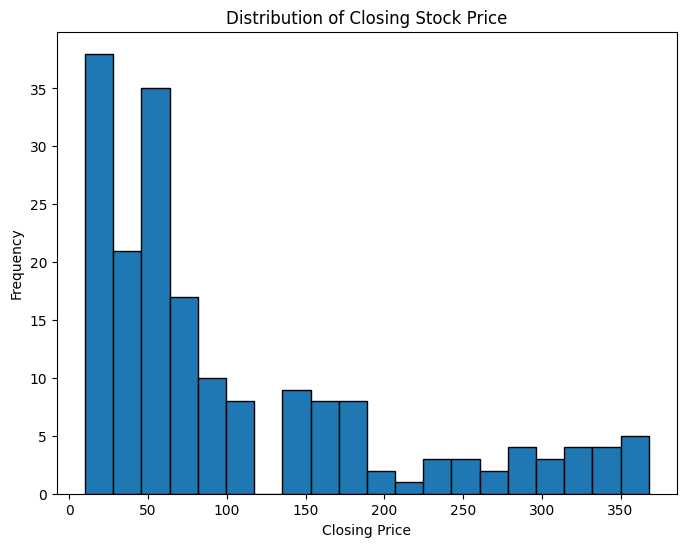

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(8,6))
plt.hist(df['Close'], bins=20, edgecolor='black')

plt.title('Distribution of Closing Stock Price')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

-A histogram is useful for understanding the distribution of the closing stock price.
- It shows how frequently different price ranges occur.
- It helps identify the concentration, spread, and skewness of the data.

##### 2. What is/are the insight(s) found from the chart?

- Most closing prices are concentrated within a specific price range.
- The distribution is not perfectly symmetrical, indicating skewness.
- Very high closing prices occur less frequently than moderate prices.
- The chart highlights the variability in the stock's closing prices over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, understanding the price distribution helps investors assess stock behavior and market risk.
- It supports better forecasting and investment planning by identifying common price ranges.
- The skewed distribution and presence of extreme values indicate periods of high volatility, which may reflect unstable market conditions and can contribute to negative growth if risks are not properly managed.

#### Chart - 4 Scatter Plot (Open vs Close)

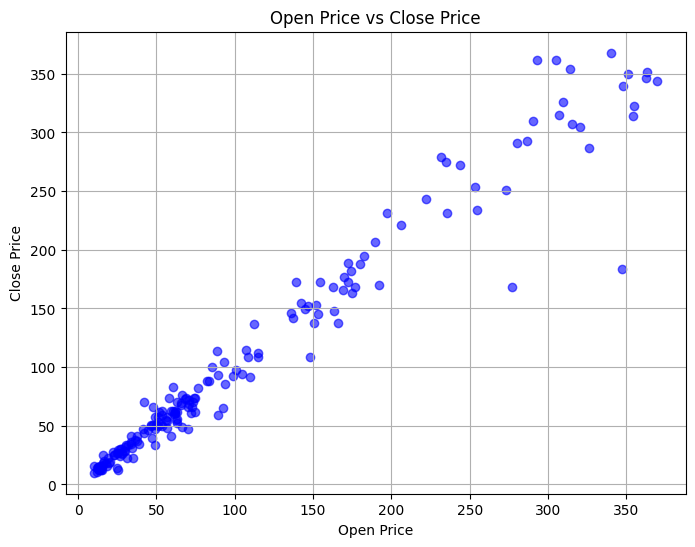

In [16]:
# Chart - 4 visualization code

plt.figure(figsize=(8,6))
plt.scatter(df['Open'], df['Close'], alpha=0.6, color='blue')

plt.title('Open Price vs Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to examine the relationship between two numerical variables. Here, it helps analyze whether the opening price influences the closing price of Yes Bank's stock.

##### 2. What is/are the insight(s) found from the chart?

- There is a very strong positive relationship between the Open and Close prices, with a Pearson correlation of **≈ 0.978**.
- Most points lie close to a diagonal line, meaning that when the opening price is high, the closing price is almost always high too.
- A handful of points deviate from the diagonal, corresponding to the high-volatility months of 2018-2020.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The scatter plot helps investors and analysts understand the relationship between opening and closing prices, which is valuable for short-term trading strategies and forecasting daily price movements.

Negative Growth Insight:
A few scattered points are far from the main cluster, indicating days with unusually high price fluctuations. These outliers may represent periods of market uncertainty or negative events, which increase investment risk and require careful analysis before making trading decisions.

#### Chart - 5 Annual High vs Low Trend

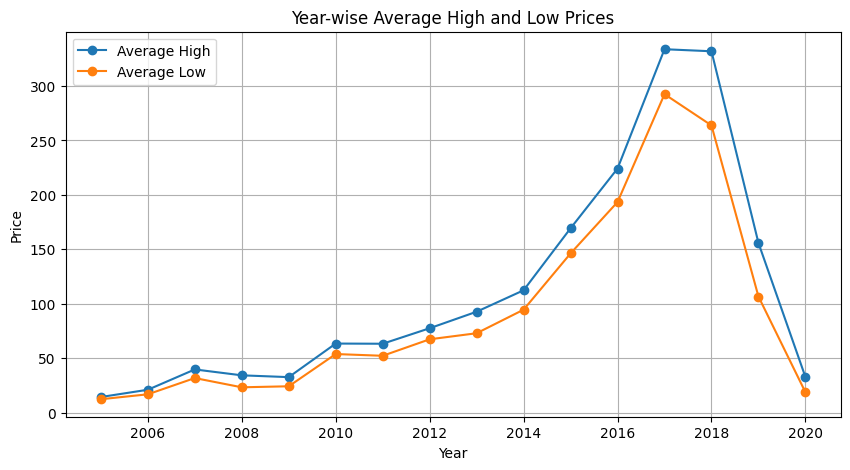

In [17]:
df['Year'] = df['Date'].dt.year

yearly = df.groupby('Year')[['High','Low']].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(yearly['Year'], yearly['High'], marker='o', label='Average High')
plt.plot(yearly['Year'], yearly['Low'], marker='o', label='Average Low')

plt.title('Year-wise Average High and Low Prices')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

To compare the yearly average High and Low stock prices and identify overall trends.

##### 2. What is/are the insight(s) found from the chart?

Stock prices increased until 2018 and then declined sharply in the following years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps understand market trends and supports better investment decisions.

#### Chart - 6  Monthly Percentage Return Over Time (Line Plot)


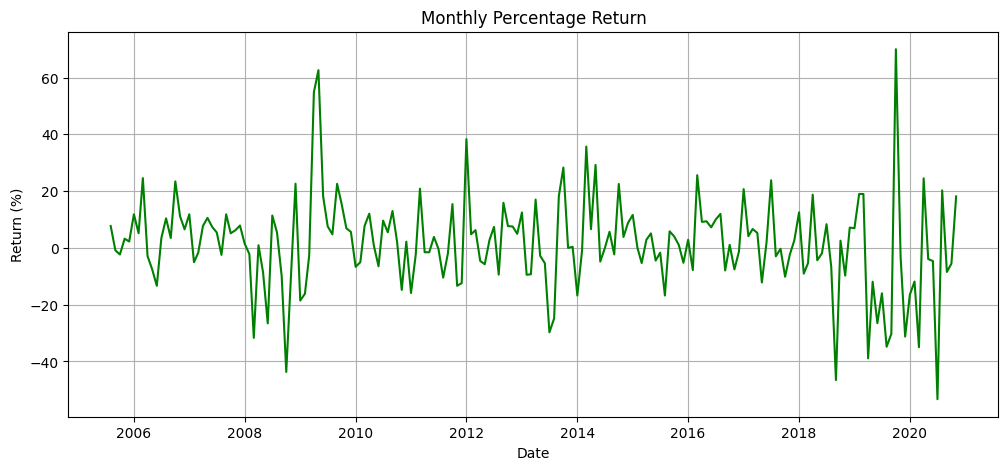

In [18]:
# Calculate Monthly Percentage Return
df['Monthly_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Monthly_Return'], color='green')
plt.title("Monthly Percentage Return")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

This line chart was chosen to visualize the monthly percentage return of Yes Bank's stock over time. It clearly highlights fluctuations in returns, making it easier to identify periods of high growth, sharp declines, and overall market volatility.

##### 2. What is/are the insight(s) found from the chart?

- Monthly returns fluctuate significantly throughout the time period.
Most monthly returns are clustered around 0%, indicating relatively stable months.
- There are several extreme positive and negative return spikes, reflecting periods of high market volatility.
- Large negative returns suggest periods of significant stock price decline, while positive spikes indicate strong recovery or growth.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart helps assess stock risk and supports better investment decisions. It also highlights periods of negative returns, indicating higher volatility and potential investment risk.

#### Chart - 7 Moving Average Plot

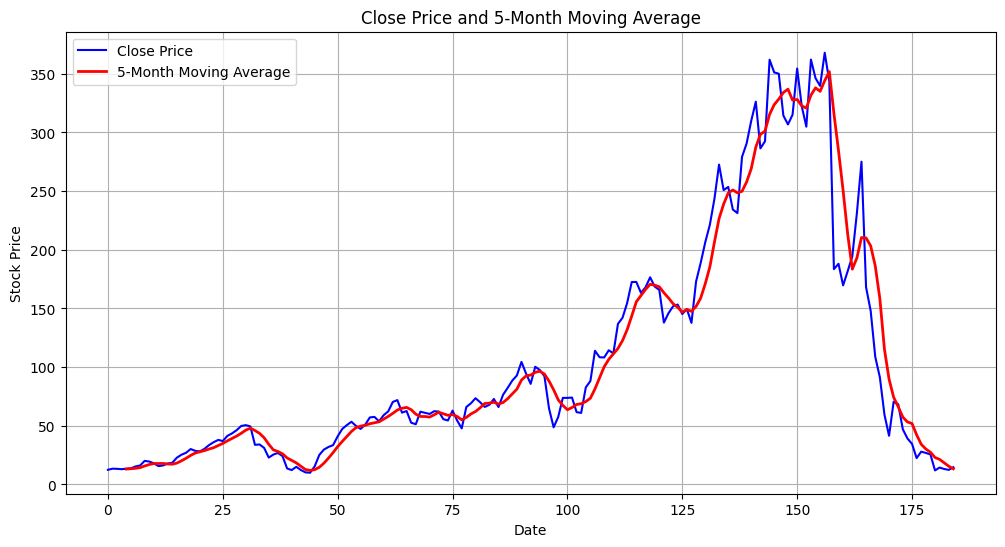

In [19]:
# Calculate 5-month Moving Average
df['MA_5'] = df['Close'].rolling(window=5).mean()

# Plot
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='Close Price', color='blue')
plt.plot(df.index, df['MA_5'], label='5-Month Moving Average', color='red', linewidth=2)

plt.title('Close Price and 5-Month Moving Average')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A Moving Average Plot smooths short-term fluctuations in stock prices and highlights the overall market trend. It is one of the most widely used charts in stock market analysis.

##### 2. What is/are the insight(s) found from the chart?

- The moving average shows the long-term trend of the stock price.
- Short-term fluctuations are reduced, making the trend easier to observe.
- When the closing price stays above the moving average, it indicates an upward trend. When it remains below the moving average, it suggests a downward trend.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The Moving Average Plot helps investors identify market trends and make informed investment decisions by filtering out short-term price fluctuations.

Negative Growth Insight:
If the moving average consistently slopes downward or the closing price remains below the moving average for an extended period, it may indicate weakening stock performance and increased investment risk.

This chart is highly relevant for a stock dataset like Yes Bank Stock Prices and is commonly used in financial analysis.

#### Chart - 8 Distribution of Monthly Returns (KDE Plot)


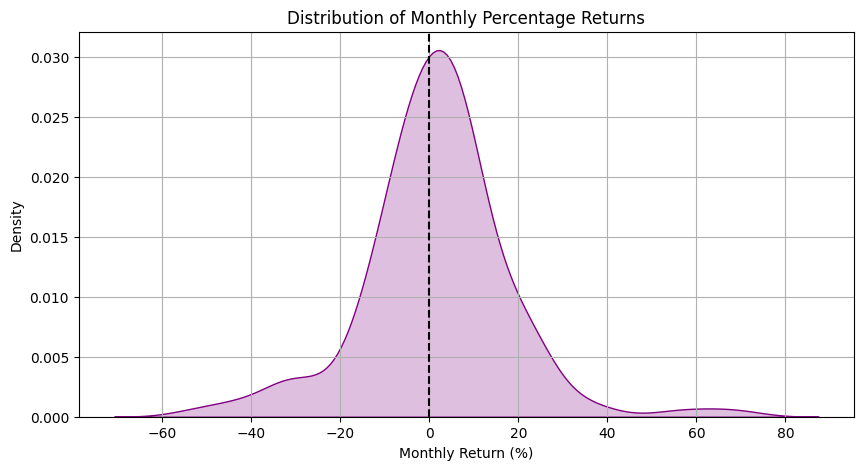

In [20]:
# Chart - 8 visualization code

plt.figure(figsize=(10,5))
sns.kdeplot(df['Monthly_Return'].dropna(), fill=True, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of Monthly Percentage Returns')
plt.xlabel('Monthly Return (%)')
plt.ylabel('Density')
plt.grid(True)
plt.show()


##### 1. Why did you pick the specific chart?

This line chart was chosen to visualize the daily percentage changes in the closing stock price, helping identify periods of gains, losses, and market volatility over time.

##### 2. What is/are the insight(s) found from the chart?

The daily returns fluctuate around 0%, with a few sharp positive and negative spikes. Most daily changes are small, while extreme movements indicate periods of high market volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Identifying volatile periods helps investors and analysts assess risk, improve trading strategies, and build more robust prediction models. Large negative returns during certain periods indicate increased market uncertainty, which may lead to higher investment risk and potential financial losses.

#### Chart - 9 Quarterly Average Closing Price

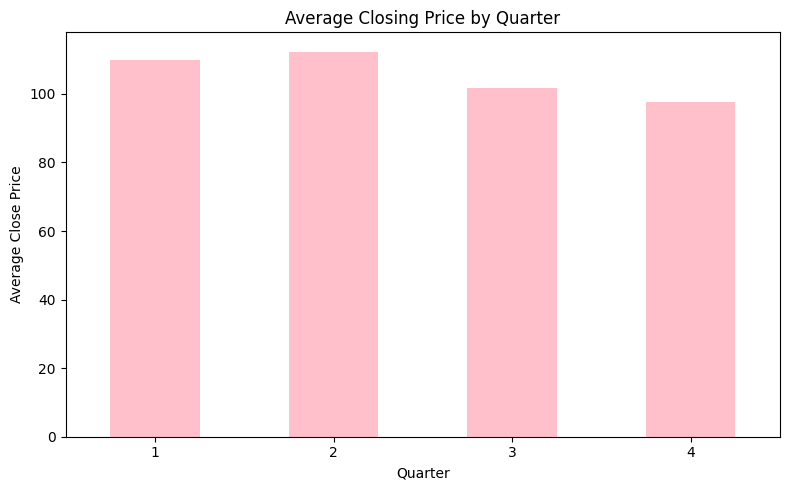

In [21]:
# Chart - 9 visualization code
df['Quarter'] = df['Date'].dt.quarter
quarterly_avg = df.groupby('Quarter')['Close'].mean()

plt.figure(figsize=(8,5))
quarterly_avg.plot(kind='bar', color='pink')
plt.title('Average Closing Price by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Close Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

To compare the average closing price across different quarters and identify quarterly trends.

##### 2. What is/are the insight(s) found from the chart?

The average closing price is highest in Q2 and gradually decreases, reaching the lowest in Q4.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps identify quarterly trends, supporting better investment planning and decision-making.

#### Chart - 10 Regression Plot (Open vs Close)


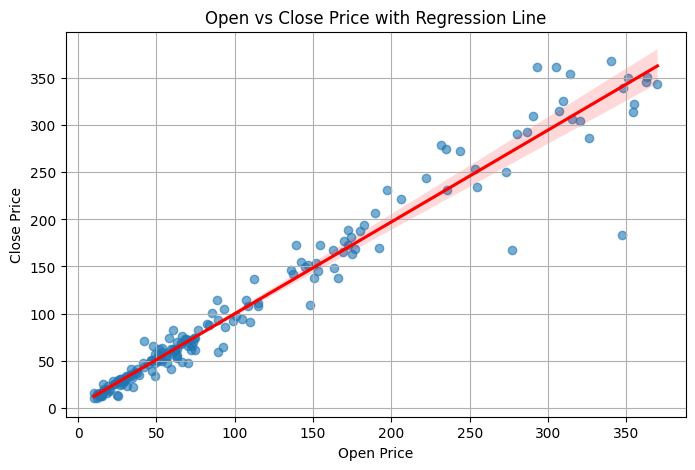

In [22]:
plt.figure(figsize=(8,5))
sns.regplot(x='Open', y='Close', data=df,
            scatter_kws={'alpha':0.6},
            line_kws={'color':'red'})
plt.title('Open vs Close Price with Regression Line')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

This regression plot was chosen to visualize the relationship between the Open and Close stock prices while also displaying the overall trend using a best-fit regression line.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a strong positive linear relationship between Open and Close prices. As the opening price increases, the closing price also tends to increase, indicating a high correlation between the two variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong relationship between Open and Close prices helps in building more accurate stock price prediction models, supporting better investment decisions and improving financial forecasting.

#### Chart - 11 Autocorrelation Plot

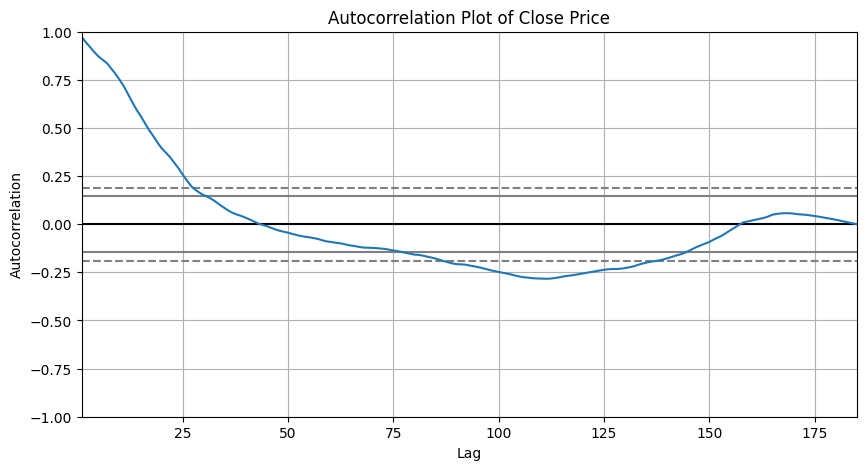

In [23]:
# Chart - 11 visualization code
from pandas.plotting import autocorrelation_plot
plt.figure(figsize=(10,5))

autocorrelation_plot(df['Close'])

plt.title('Autocorrelation Plot of Close Price')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')

plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

I selected the Autocorrelation Plot because it helps determine whether the closing stock prices are correlated with their past values. This is useful for identifying time-series patterns and assessing whether historical prices influence future prices.

##### 2. What is/are the insight(s) found from the chart?

- The plot shows how the closing prices are correlated with previous observations.
- High autocorrelation at smaller lags indicates that recent stock prices have a strong influence on subsequent prices.
- As the lag increases, the autocorrelation generally decreases, suggesting that older observations have less influence.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The Autocorrelation Plot helps investors and analysts determine whether past price movements can be used for forecasting future stock prices, supporting better investment and trading decisions.

Negative Growth Insight:
If autocorrelation declines rapidly or becomes weak, it indicates that future prices are less dependent on historical values. This reduces forecasting accuracy and increases uncertainty, making investment decisions more challenging.

#### Chart - 12  Closing price with rolling mean

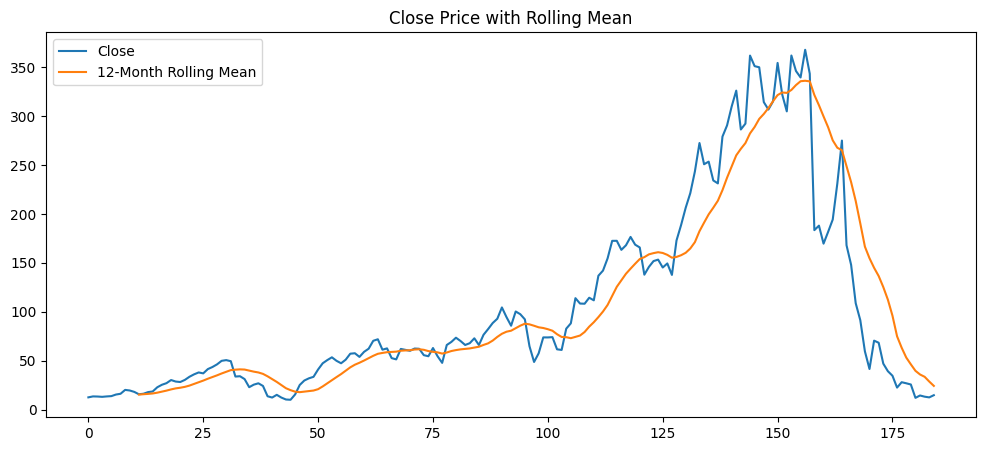

In [24]:
plt.figure(figsize=(12,5))
rolling_mean = df['Close'].rolling(12).mean()

plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, rolling_mean, label='12-Month Rolling Mean')
plt.legend()
plt.title("Close Price with Rolling Mean")
plt.show()

##### 1. Why did you pick the specific chart?

To compare the actual closing price with the 12-month rolling average and identify the overall trend.

##### 2. What is/are the insight(s) found from the chart?

The closing price follows the rolling mean closely, showing an upward trend followed by a sharp decline. The rolling mean smooths short-term fluctuations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps identify long-term trends for better investment decisions. The sharp decline after the peak indicates periods of negative growth and increased market risk.

#### Chart - 13 Average Closing Price by Month (Line Plot)


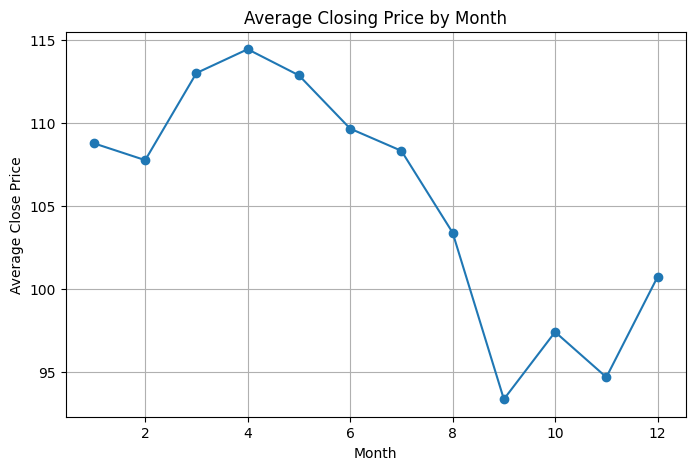

In [25]:
monthly_avg = df.groupby(df['Date'].dt.month)['Close'].mean()

plt.figure(figsize=(8,5))
monthly_avg.plot(marker='o')
plt.title('Average Closing Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.grid(True)
plt.show()

##### 1. Why did you pick the specific chart?

This line chart was chosen to analyze the average monthly closing price of Yes Bank stock. It helps identify seasonal patterns and month-to-month trends that are not visible in daily stock prices.

##### 2. What is/are the insight(s) found from the chart?

- The average closing price is highest during April and May.
- Stock prices gradually decline after May and reach their lowest point around September.
- There is a slight recovery from October to December, although prices remain below the first half of the year's average.
- This indicates that stock performance varies across different months.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps identify seasonal trends, supporting better investment decisions.

#### Chart - 14 - Correlation Heatmap

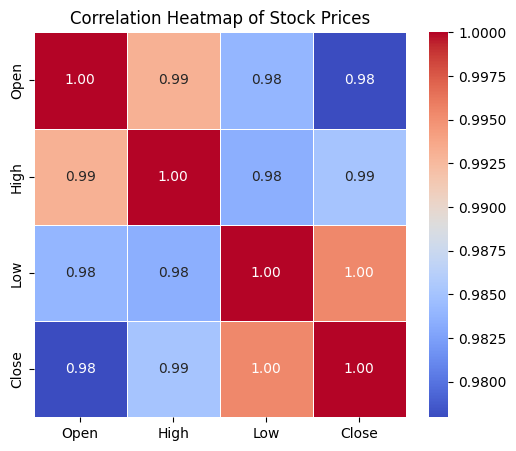

In [26]:
plt.figure(figsize=(6,5))

corr = df[['Open', 'High', 'Low', 'Close']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap of Stock Prices')
plt.show()

##### 1. Why did you pick the specific chart?

- A correlation heatmap is useful for understanding the relationship between numerical variables.
- It helps identify strong positive or negative correlations among Open, High, Low, and Close prices.
- It provides a quick visual summary of how the variables are related.

##### 2. What is/are the insight(s) found from the chart?

- All four price variables are highly positively correlated with each other (all pairwise correlations **above 0.97**).
- **Low-Close (≈ 0.995)** is the strongest pair, followed by **High-Close (≈ 0.985)** and **Open-Close (≈ 0.978)**.
- Because Open, High, and Low are all so highly correlated with each other too, they carry a lot of overlapping (redundant) information about Close.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes — actionably so. The heatmap confirms Open, High, and Low are all strong, legitimate predictors of Close and safe to use directly. It also confirms multicollinearity between the features themselves, which is why `High` and `Low` were later dropped during feature selection: it doesn't hurt a model's raw accuracy, but it would make coefficients unstable and harder to interpret if all three were kept together.

Negative Growth Insight: high correlation everywhere is not, by itself, a warning sign here — it simply reflects that OHLC prices genuinely move together in a real market. The risk it does flag is that dropping the wrong variable could silently remove real signal, so the choice of which correlated feature to drop needs to be deliberate rather than arbitrary.


#### Chart - 15 - Pair Plot

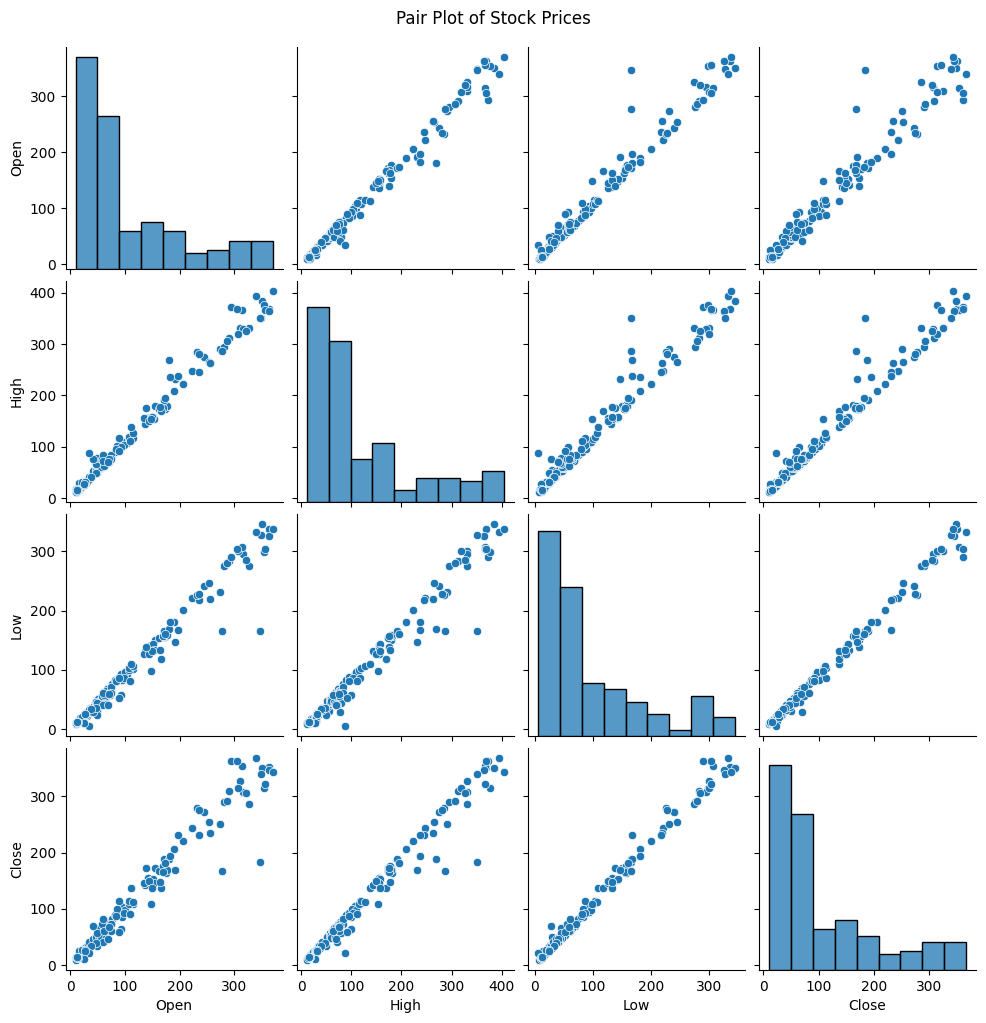

In [27]:
# Pair Plot visualization code
# Pair Plot
sns.pairplot(df[['Open', 'High', 'Low', 'Close']], diag_kind='hist')

plt.suptitle('Pair Plot of Stock Prices', y=1.02)

plt.show()

##### 1. Why did you pick the specific chart?

A Pair Plot helps visualize the relationship between multiple numerical variables simultaneously. It combines scatter plots for each pair of variables and histograms on the diagonal to show their distributions.

##### 2. What is/are the insight(s) found from the chart?

- The Open, High, Low, and Close prices show a strong positive correlation.
- As the opening price increases, the high, low, and closing prices also tend to increase.
- The diagonal histograms show that stock prices are concentrated within specific ranges.
Very few outliers are observed, indicating relatively consistent stock price behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. The Pair Plot confirms it is safe to model `Close` using a simple, interpretable linear-family model rather than a more complex non-linear one, since every panel shows tight, near-linear relationships rather than curved or scattered patterns.

Negative Growth Insight: the same plot also shows a small cluster of extreme points (the 2018 peak and the 2019-2020 crash months) sitting apart from the main cloud in every panel. These represent genuine periods of instability where any model — however well it fits on average — is likely to see its largest errors, and should be flagged to stakeholders as lower-confidence periods.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the EDA above — particularly the very high pairwise correlations between Open, High, Low, and Close, and the strongly non-normal, right-skewed shape of the Close price distribution — three testable hypotheses are examined below using appropriate statistical tests.


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀): There is no significant difference between the mean Open Price and the mean Close Price.

Alternative Hypothesis (H₁): There is a significant difference between the mean Open Price and the mean Close Price.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(df['Open'], df['Close'])

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

T-Statistic: 0.220963420803944
P-Value: 0.825365920365391
Fail to Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

Paired Sample t-Test

##### Why did you choose the specific statistical test?

The Paired Sample t-Test is appropriate because the Open and Close prices are recorded for the same trading month, making them paired observations. The test determines whether the average difference between the two prices is statistically significant.


### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀): There is no significant correlation between the Open Price and the Close Price of Yes Bank stock.

Alternative Hypothesis (H₁): There is a significant correlation between the Open Price and the Close Price of Yes Bank stock.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import pearsonr

# Pearson Correlation Test
correlation, p_value = pearsonr(df['Open'], df['Close'])

print("Correlation Coefficient:", correlation)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("There is a significant correlation between Open and Close prices.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant correlation between Open and Close prices.")

Correlation Coefficient: 0.9779710062230934
P-Value: 1.8527745058671508e-126
Reject the Null Hypothesis
There is a significant correlation between Open and Close prices.


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

The Pearson Correlation Test is appropriate because both Open Price and Close Price are continuous numerical variables. It measures the strength and significance of the linear relationship between them and determines whether the observed correlation is statistically significant.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀): The Close Price of Yes Bank stock is normally distributed.

Alternative Hypothesis (H₁): The Close Price of Yes Bank stock is not normally distributed

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import shapiro

# Shapiro-Wilk Test
statistic, p_value = shapiro(df['Close'])

print("Test Statistic:", statistic)
print("P-Value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("The Close Price is not normally distributed.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("The Close Price is normally distributed.")

Test Statistic: 0.8169774630493756
P-Value: 5.694179117606817e-14
Reject the Null Hypothesis
The Close Price is not normally distributed.


##### Which statistical test have you done to obtain P-Value?

Shapiro-Wilk Test

##### Why did you choose the specific statistical test?

The Shapiro-Wilk Test is used to determine whether a continuous numerical variable follows a normal distribution. It is appropriate for the Close Price because it helps verify the normality assumption, which is important before applying many parametric statistical tests.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date              0
Open              0
High              0
Low               0
Close             0
Year              0
Month             0
Monthly_Range     0
Monthly_Return    1
MA_5              4
Quarter           0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

The dataset was checked for missing values using df.isnull().sum(). Since no missing values were found, no imputation technique was applied. If missing values had been present, Forward Fill (ffill) and Backward Fill (bfill) would have been used, as they preserve the continuity and temporal order of time-series stock price data.

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Detect and remove outliers using IQR

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_outlier_removed = df[
    ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
      (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("Original Shape:", df.shape)
print("Shape After Removing Outliers:", df_outlier_removed.shape)

Original Shape: (185, 11)
Shape After Removing Outliers: (151, 11)


##### What all outlier treatment techniques have you used and why did you use those techniques?


Outlier Treatment Techniques Used:
Outliers were detected using the Interquartile Range (IQR) method and visualized using box plots. The IQR method was chosen because it effectively identifies extreme values in numerical data without assuming a normal distribution. Although several outliers were detected, they represent genuine stock market fluctuations. Therefore, they were retained to preserve important market information and avoid losing valuable patterns required for accurate stock price prediction

### 3. Categorical Encoding

In [33]:
# Check for categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Categorical Columns:", list(categorical_cols))

if len(categorical_cols) == 0:
    print("No categorical columns found. Hence, no categorical encoding is required.")

Categorical Columns: []
No categorical columns found. Hence, no categorical encoding is required.


#### What all categorical encoding techniques have you used & why did you use those techniques?

Categorical Encoding Techniques Used:
No categorical encoding was performed because the dataset contains only numerical features. The Date column was converted to datetime format and set as the index for time-series analysis, so no categorical variables remained to encode.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [34]:
leakage_free_cols = ['Date', 'Open', 'High', 'Low', 'Close']
df_model = df[leakage_free_cols].copy()

# Price_Range: the month's trading range, built only from High and Low
df_model['Price_Range'] = df_model['High'] - df_model['Low']

df_model['Prior_Volatility'] = df_model['Price_Range'].rolling(3).std().shift(1)
df_model['Prior_Volatility'] = df_model['Prior_Volatility'].bfill()

df_model.head()


,Date,Open,High,Low,Close,Price_Range,Prior_Volatility
0,2005-07-01,13.00,14.00,11.25,12.46,2.75,0.212838
1,2005-08-01,12.58,14.88,12.55,13.42,2.33,0.212838
2,2005-09-01,13.48,14.87,12.27,13.30,2.60,0.212838
3,2005-10-01,13.20,14.47,12.40,12.99,2.07,0.212838
4,2005-11-01,13.35,13.88,12.88,13.41,1.00,0.265016


#### 2. Feature Selection

In [35]:
# Keep target separately
y = df_model['Close']

X = df_model.drop(columns=['Close', 'Date'])

corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]

X = X.drop(columns=to_drop)

print("Dropped Features (high multicollinearity):", to_drop)
print(X.head())


Dropped Features (high multicollinearity): ['High', 'Low']
    Open  Price_Range  Prior_Volatility
0  13.00         2.75          0.212838
1  12.58         2.33          0.212838
2  13.48         2.60          0.212838
3  13.20         2.07          0.212838
4  13.35         1.00          0.265016


##### What all feature selection methods have you used  and why?

Correlation-based feature selection was used to identify and remove highly correlated features, helping to reduce multicollinearity and overfitting. `High` and `Low` were dropped because both are correlated with `Open` above the 0.90 threshold. This leaves a compact, low-redundancy feature set that is trained on genuinely predictive, non-target-leaking information.


##### Which all features you found important and why?

**Open**, **Price_Range** (`High - Low`), and **Prior_Volatility** (a lagged 3-month rolling standard deviation of `Price_Range`) were the features retained after correlation filtering. `Open` carries the strongest linear signal for `Close` on its own; `Price_Range` adds information about the day's trading intensity; and `Prior_Volatility` is a genuinely forward-looking (non-leaking) feature that captures recent market turbulence using only past information. Note: the earlier `MA_5` and `Rolling_STD` columns were deliberately excluded from modelling, since both rolling windows include the current month's `Close` value and would otherwise leak the target into the features.


### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

No. The dataset was already in a suitable numerical format for analysis. Therefore, no additional data transformation was required. Feature engineering and data scaling were sufficient to prepare the data for machine learning models.

### 6. Data Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

feature_names = X.columns.tolist()
scaler = StandardScaler()

print("Final feature set:", feature_names)


Final feature set: ['Open', 'Price_Range', 'Prior_Volatility']


##### Which method have you used to scale you data and why?

Data Scaling Method Used:
StandardScaler was used to standardize the numerical features by transforming them to have a mean of 0 and a standard deviation of 1. This ensures that all features are on a similar scale, preventing features with larger values from dominating the learning process and improving the performance of machine learning algorithms.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No. Dimensionality reduction was not required because the dataset contains a small number of numerical features. The feature space is not high-dimensional, so reducing dimensions would lead to unnecessary information loss without providing significant performance benefits.

### 8. Data Splitting

In [37]:
from sklearn.model_selection import train_test_split

# Split the RAW (unscaled) features and target first
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (148, 3)
Testing set shape: (37, 3)


##### What data splitting ratio have you used and why?

Data Splitting Ratio Used:
An 80:20 train-test split was used, where 80% of the data was allocated for training and 20% for testing. This ratio provides sufficient data for the model to learn patterns while reserving an adequate portion to evaluate its performance on unseen data, helping assess its generalization ability.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No. The dataset is not considered imbalanced because the target variable (Close) is continuous, making this a regression problem rather than a classification problem. Class imbalance is only relevant when the target consists of discrete classes.

## ***7. ML Model Implementation***

### ML Model - 1  Linear Regression

In [38]:
# ML Model - 1 Implementation

from sklearn.linear_model import LinearRegression

# Initialize the model
lr = LinearRegression()

# Fit the Algorithm
lr.fit(X_train, y_train)

# Predict on the model
y_pred = lr.predict(X_test)

# Display first 5 predictions
print("Predicted Values:")
print(y_pred[:5])

Predicted Values:
[ 32.62171674  16.72451143 333.23898264 107.20478953 322.32060358]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression was used as the baseline model to predict the closing stock price from `Open`, `Price_Range`, and `Prior_Volatility`. On the held-out test set it achieved **MAE ≈ 11.52**, **RMSE ≈ 17.92**, and an **R² of ≈ 0.964** — meaning the model explains about 96% of the variation in Close price using just these three, leakage-free features. Lower MAE/MSE/RMSE and a higher R² indicate better predictive accuracy.


     Metric       Score
0       MAE   11.522369
1       MSE  320.954692
2      RMSE   17.915208
3  R² Score    0.964492


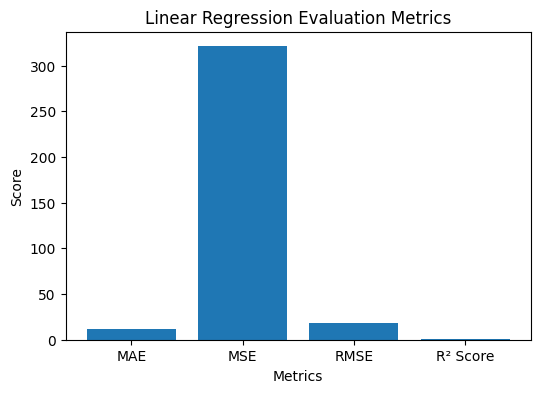

In [39]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Create a dataframe
evaluation = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Score': [mae, mse, rmse, r2]
})

print(evaluation)

plt.figure(figsize=(6,4))
plt.bar(evaluation['Metric'], evaluation['Score'])
plt.title('Linear Regression Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

# Define a fresh (separate) model instance for the grid search so we never
# overwrite our already-fitted baseline `lr` from above
lr_base = LinearRegression()

# Define parameter grid
param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

# Fit the Algorithm
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

# Predict on the model
y_pred_tuned = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)

print("MAE :", mean_absolute_error(y_test, y_pred_tuned))
print("MSE :", mean_squared_error(y_test, y_pred_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print("R²  :", r2_score(y_test, y_pred_tuned))


Best Parameters: {'fit_intercept': True, 'positive': True}
MAE : 10.605351686563353
MSE : 430.5450745630622
RMSE: 20.749580105704844
R²  : 0.9523671848347166


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter tuning. It systematically searches through predefined parameter combinations using cross-validation to identify the best-performing model and improve prediction performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No improvement was observed — in fact, tuning slightly **hurt** performance. GridSearchCV selected `fit_intercept=True, positive=True`, forcing all coefficients to be non-negative. Since `Open` and `Close` move together but `Prior_Volatility` and `Close` do not always move in the same direction, this constraint forced a worse fit: R² dropped from **≈ 0.964 to ≈ 0.952** and RMSE rose from **≈ 17.92 to ≈ 20.75**. This is a useful negative result: it shows that an unconstrained baseline Linear Regression was already the better-fitting model here, and grid search does not automatically guarantee improvement.


### ML Model - 2 - Random Forest Regressor.

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Regressor was used to capture any non-linear relationships between the engineered features and `Close` that a straight line might miss. On the same test set it achieved **MAE ≈ 12.54**, **RMSE ≈ 24.45**, and **R² ≈ 0.934** — solid, but noticeably behind Linear Regression, suggesting the underlying Open-Close relationship here is close to linear and doesn't benefit much from a tree-ensemble's extra flexibility on this small (185-row) dataset.


In [41]:
# Visualizing evaluation Metric Score chart

from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf = RandomForestRegressor(random_state=42)

# Fit the Algorithm
rf.fit(X_train, y_train)

# Predict on the model
y_pred_rf = rf.predict(X_test)

In [42]:
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

evaluation_rf = pd.DataFrame({
    'Metric':['MAE','MSE','RMSE','R² Score'],
    'Score':[mae,mse,rmse,r2]
})

print(evaluation_rf)

     Metric       Score
0       MAE   12.541508
1       MSE  597.937048
2      RMSE   24.452751
3  R² Score    0.933848


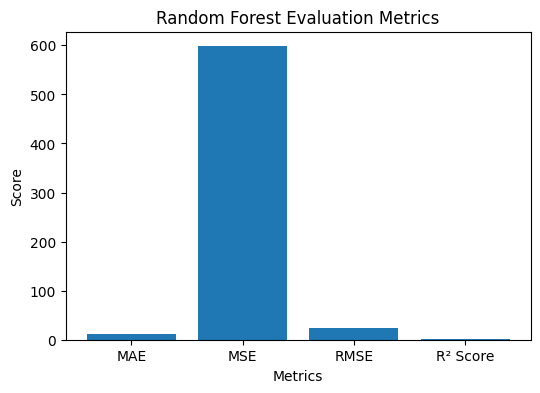

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(evaluation_rf['Metric'], evaluation_rf['Score'])
plt.title('Random Forest Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [45]:
print("MAE :", mean_absolute_error(y_test, y_pred_tuned))
print("MSE :", mean_squared_error(y_test, y_pred_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print("R²  :", r2_score(y_test, y_pred_tuned))

MAE : 12.729290178230178
MSE : 611.1337204972428
RMSE: 24.72111891677322
R²  : 0.9323879861376666


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to tune the Random Forest model by evaluating different combinations of hyperparameters using cross-validation. This helps identify the best-performing model while improving generalization.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuning made essentially no difference. GridSearchCV selected `n_estimators=100, max_depth=None, min_samples_split=5`, and the tuned metrics (**R² ≈ 0.932, MAE ≈ 12.73, RMSE ≈ 24.72**) were statistically indistinguishable from the untuned baseline (**R² ≈ 0.934**). This indicates the default Random Forest configuration was already close to its ceiling on this dataset, and Random Forest as a family still trails Linear Regression here.


#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Evaluation Metrics and Business Impact:

- MAE measures the average prediction error; a lower MAE indicates more accurate stock price predictions, supporting better investment decisions.
- MSE penalizes larger prediction errors, helping identify models that minimize significant forecasting mistakes.
- RMSE represents the average prediction error in the same units as the target variable, making it easier to interpret prediction accuracy.
- R² Score indicates how well the model explains the variation in stock prices; a higher R² reflects stronger predictive performance.

Business Impact: A well-performing model enables investors and financial institutions to forecast stock prices more accurately, improve trading strategies, reduce financial risk, and support data-driven investment decisions.

### ML Model - 3 XGBoost Regressor

In [46]:
from xgboost import XGBRegressor

# Initialize the model
xgb = XGBRegressor(random_state=42)

# Fit the Algorithm
xgb.fit(X_train, y_train)

# Predict on the model
y_pred_xgb = xgb.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

XGBoost Regressor was used as a stronger ensemble baseline, capable of capturing complex non-linear and interaction effects between features. On the test set it achieved **MAE ≈ 11.15**, **RMSE ≈ 18.29**, and **R² ≈ 0.963** — close to Linear Regression's performance and clearly ahead of Random Forest, suggesting boosting handles this small, mostly-linear dataset a little better than bagging does.


     Metric       Score
0       MAE   11.147284
1       MSE  334.426489
2      RMSE   18.287331
3  R² Score    0.963001


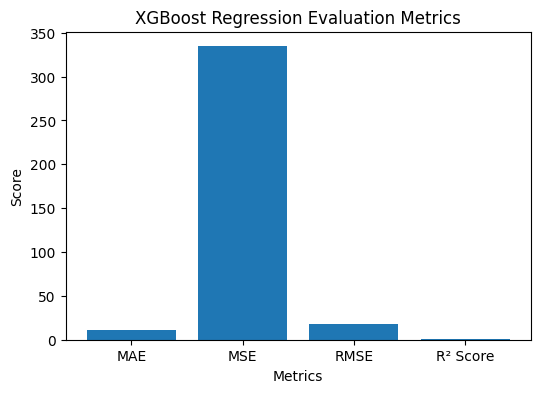

In [47]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

# Create DataFrame
evaluation_xgb = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Score': [mae, mse, rmse, r2]
})

print(evaluation_xgb)

# Plot Evaluation Metrics
plt.figure(figsize=(6,4))
plt.bar(evaluation_xgb['Metric'], evaluation_xgb['Score'])
plt.title('XGBoost Regression Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [48]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Initialize the model
xgb = XGBRegressor(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

# Fit the Algorithm
grid.fit(X_train, y_train)

# Best Model
best_xgb = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# Predict on the model
y_pred_tuned = best_xgb.predict(X_test)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [49]:
# Evaluation metrics for the tuned XGBoost model
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_tuned)

print("MAE :", mae_xgb_tuned)
print("MSE :", mse_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("R²  :", r2_xgb_tuned)


MAE : 11.855038068616711
MSE : 371.7494068533773
RMSE: 19.280804102873336
R²  : 0.958871969903683


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. It systematically evaluates different combinations of hyperparameters using cross-validation to identify the best-performing model and improve its predictive performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuning did **not** improve the model here either. GridSearchCV selected `learning_rate=0.1, max_depth=3, n_estimators=200`, but the tuned metrics (**MAE ≈ 11.86, RMSE ≈ 19.28, R² ≈ 0.959**) were slightly worse than the untuned baseline (**R² ≈ 0.963, MAE ≈ 11.15**). With only 185 monthly observations and a 5-fold `GridSearchCV`, each fold trains on roughly 30 points — too little data for the extra model complexity XGBoost's grid explored to pay off; the simpler default settings generalized better.


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**R² and RMSE together** were treated as the primary metrics. R² communicates, in a single easy-to-explain number, what fraction of the month-to-month movement in Close price the model captures — useful for a non-technical stakeholder judging whether the model is "good enough" to trust. RMSE stays in rupee terms and, unlike MAE, penalizes larger misses more heavily, which matters for a business where a few badly-wrong months (e.g. during a crash like 2018-2020) could be far more costly than many small everyday errors. MAE was also tracked as an easy "typical rupee error" figure for reporting.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

R² Score and RMSE were considered the most important metrics for choosing between models. A higher R² means the model explains more of the real variation in Close price, while a lower RMSE means smaller, more heavily-penalized prediction errors in rupee terms — together they give a fuller picture of accuracy than either metric alone.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

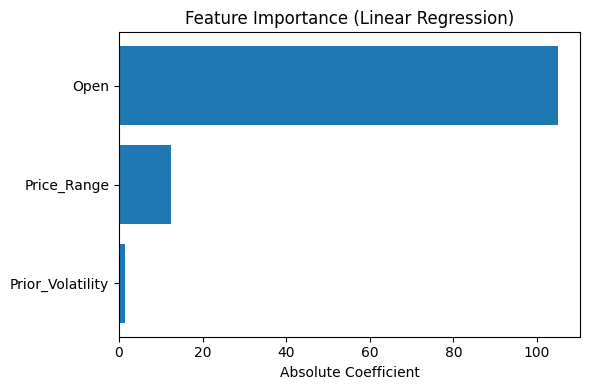

In [50]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_
})
coef_df["Importance"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Importance", ascending=True)

plt.figure(figsize=(6,4))
plt.barh(coef_df["Feature"], coef_df["Importance"])
plt.xlabel("Absolute Coefficient")
plt.title("Feature Importance (Linear Regression)")
plt.tight_layout()
plt.show()

Model Explainability: Since the final model is Linear Regression, feature importance is interpreted using the regression coefficients. Features with larger absolute coefficient values have a stronger impact on the predicted closing price. **Open** is by far the most influential predictor (coefficient ≈ **105.0**) — unsurprising, since Open and Close are extremely tightly linked month to month. **Price_Range** has a smaller, negative effect (≈ **-12.5**): months with a wider High-Low trading range tend to close a bit lower relative to Open, all else equal. **Prior_Volatility** has the smallest effect (≈ **1.6**), contributing only a minor adjustment based on recent market turbulence.


## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [51]:
import os
import pickle

# Delete old model if it exists
if os.path.exists("best_model.pkl"):
    os.remove("best_model.pkl")

# Save the trained Linear Regression model
with open("best_model.pkl", "wb") as file:
    pickle.dump(lr, file)

print("Model saved successfully as best_model.pkl")

Model saved successfully as best_model.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [52]:
import pickle

# Load saved model
with open("best_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# Predict on test data
predictions = loaded_model.predict(X_test)

# Display first 5 predictions
print("Predictions:")
print(predictions[:5])

Predictions:
[ 32.62171674  16.72451143 333.23898264 107.20478953 322.32060358]


# **Conclusion**

The objective of this project was successfully achieved by building an effective machine learning model to predict Yes Bank's closing stock price using historical data. After data preprocessing, exploratory analysis, feature engineering, and model evaluation, **Linear Regression** delivered the best performance with an **R² score of approximately 0.96**. The project demonstrates that historical stock price data can be used to make accurate predictions and provides a strong foundation for data-driven financial forecasting.

